In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
df = pd.read_csv('Hotel Reservations.csv')

# EDA

In [ ]:
df.nunique()

Booking_ID                              36275
no_of_adults                                5
no_of_children                              6
no_of_weekend_nights                        8
no_of_week_nights                          18
type_of_meal_plan                           4
required_car_parking_space                  2
room_type_reserved                          7
lead_time                                 352
arrival_year                                2
arrival_month                              12
arrival_date                               31
market_segment_type                         5
repeated_guest                              2
no_of_previous_cancellations                9
no_of_previous_bookings_not_canceled       59
avg_price_per_room                       3930
no_of_special_requests                      6
booking_status                              2
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [ ]:
df.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.describe().round(2)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.00,36275.00,36275.00,36275.00,36275.00,36275.00,36275.00,36275.00,36275.00,36275.00,36275.00,36275.00,36275.00,36275.00
mean,1.84,0.11,0.81,2.20,0.03,85.23,2017.82,7.42,15.60,0.03,0.02,0.15,103.42,0.62
std,0.52,0.40,0.87,1.41,0.17,85.93,0.38,3.07,8.74,0.16,0.37,1.75,35.09,0.79
min,0.00,0.00,0.00,0.00,0.00,0.00,2017.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,2.00,0.00,0.00,1.00,0.00,17.00,2018.00,5.00,8.00,0.00,0.00,0.00,80.30,0.00
50%,2.00,0.00,1.00,2.00,0.00,57.00,2018.00,8.00,16.00,0.00,0.00,0.00,99.45,0.00
75%,2.00,0.00,2.00,3.00,0.00,126.00,2018.00,10.00,23.00,0.00,0.00,0.00,120.00,1.00
max,4.00,10.00,7.00,17.00,1.00,443.00,2018.00,12.00,31.00,1.00,13.00,58.00,540.00,5.00


C:\Users\szymo\AppData\Local\Temp\ipykernel_4928\2436193875.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='booking_status', data=df, palette=palette)


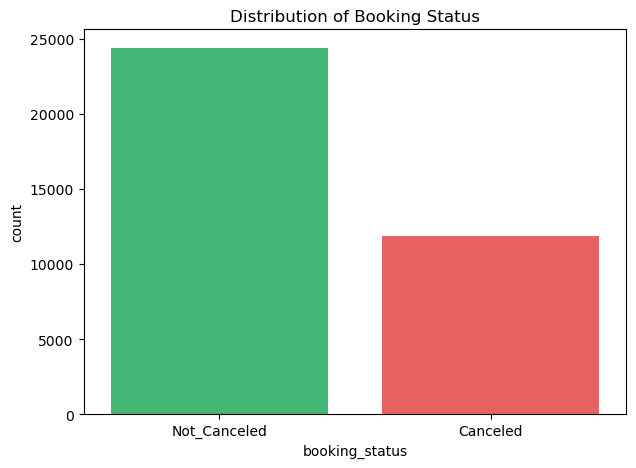

booking_status
Not_Canceled    67.236389
Canceled        32.763611
Name: proportion, dtype: float64


In [ ]:
palette={'Canceled': '#FF4B4B', 'Not_Canceled': '#2ecc71'}
plt.figure(figsize=(7, 5))
sns.countplot(x='booking_status', data=df, palette=palette)
plt.title('Distribution of Booking Status')
plt.show()

print(df['booking_status'].value_counts(normalize=True) * 100)

In [ ]:
df1 = df.drop(columns = ['Booking_ID'])

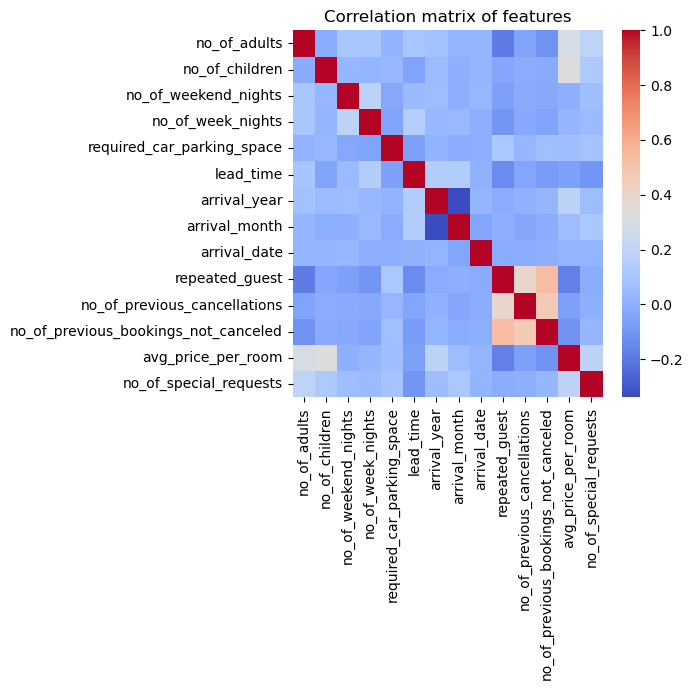

In [ ]:
corr_matrix = df1.select_dtypes(include=[np.number])
corr_matrix = corr_matrix.corr()

fig, ax = plt.subplots(figsize = (7,7))
sns.heatmap(data = corr_matrix, annot=False, cmap='coolwarm')
ax.set_title("Correlation matrix of features")
plt.tight_layout()
plt.show()

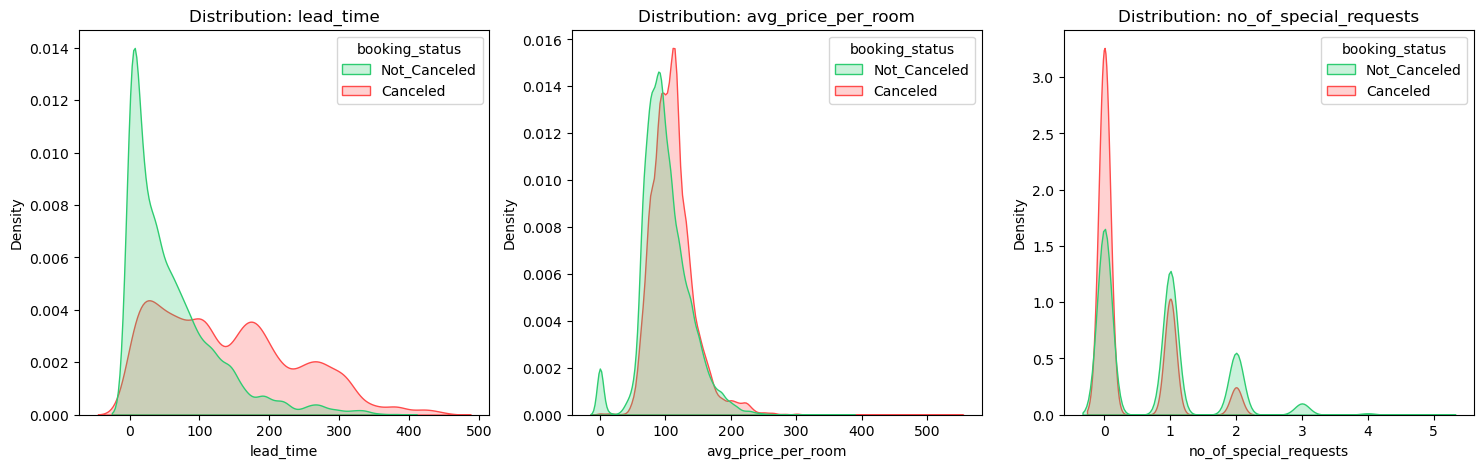

In [ ]:
numeric_features = ['lead_time', 'avg_price_per_room', 'no_of_special_requests']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(numeric_features):
    sns.kdeplot(data=df1, x=col, hue='booking_status', ax=axes[i], fill=True, common_norm=False, palette=palette)
    axes[i].set_title(f'Distribution: {col}')
plt.show()

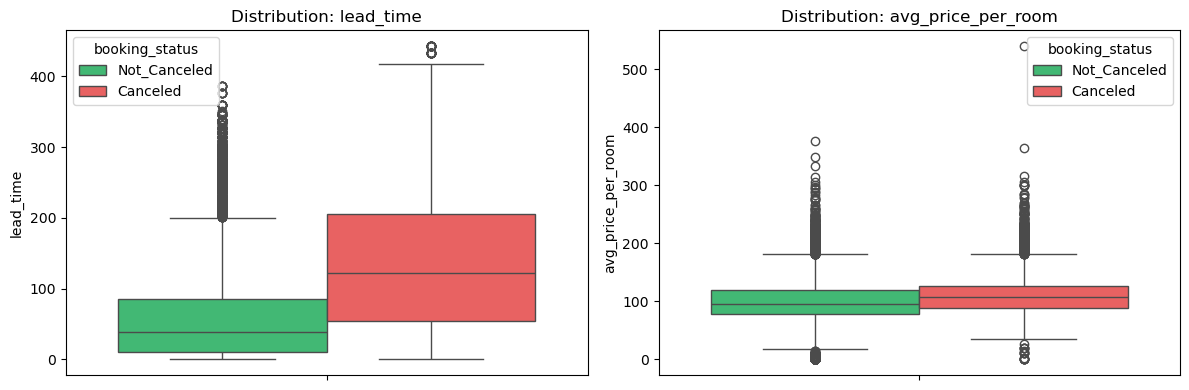

In [ ]:
cols_to_plot = ['lead_time', 'avg_price_per_room']

n_cols = 2
n_rows = math.ceil(len(cols_to_plot)/n_cols)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(12,4*n_rows))
ax = ax.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data = df1, hue = 'booking_status', y = col, ax=ax[i], palette=palette)
    ax[i].set_title(f'Distribution: {col}')

plt.tight_layout()
plt.show()


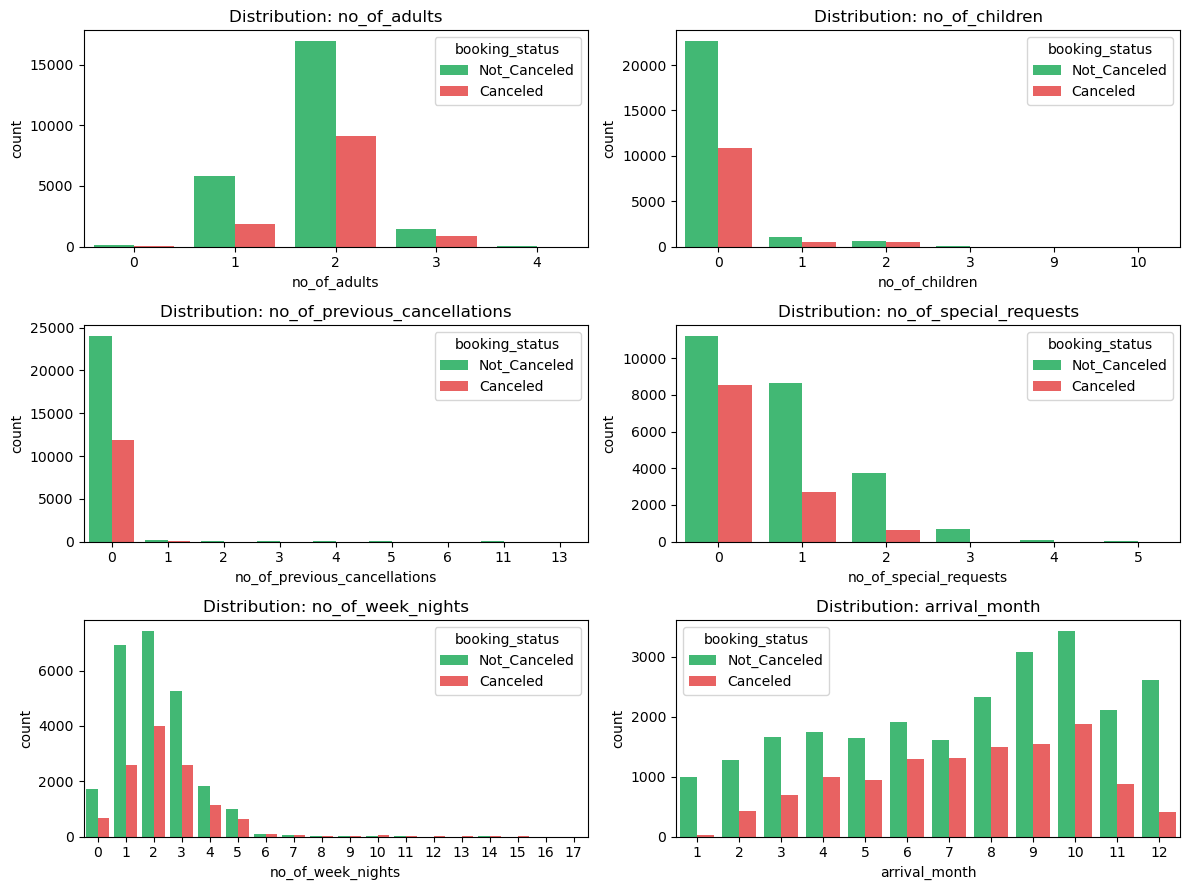

In [ ]:
cols_to_plot = ['no_of_adults', 'no_of_children','no_of_previous_cancellations', 
                'no_of_special_requests', 'no_of_week_nights', 'arrival_month']
n_cols = 2
n_rows = math.ceil(len(cols_to_plot)/n_cols)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(12,3*n_rows))
ax = ax.flatten()

for i, col in enumerate(cols_to_plot):
    sns.countplot(data = df1, hue = 'booking_status', x = col, ax=ax[i], palette=palette)
    ax[i].set_title(f'Distribution: {col}')

plt.tight_layout()
plt.show()

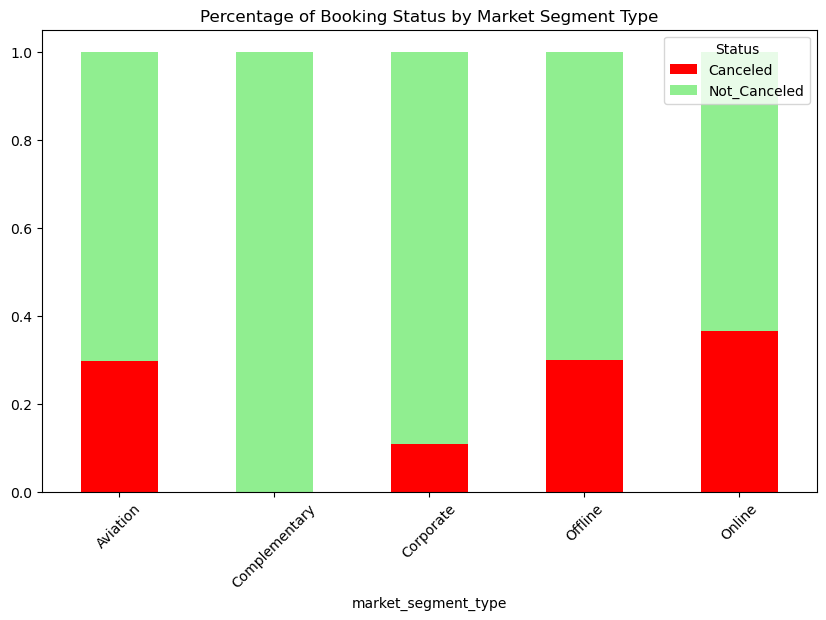

In [ ]:
market_status = pd.crosstab(df['market_segment_type'], df['booking_status'], normalize='index')
market_status.plot(kind='bar', stacked=True, figsize=(10, 6), color=['red', 'lightgreen'])
plt.title('Percentage of Booking Status by Market Segment Type')
plt.legend(title='Status', loc='upper right')
plt.xticks(rotation=45)
plt.show()

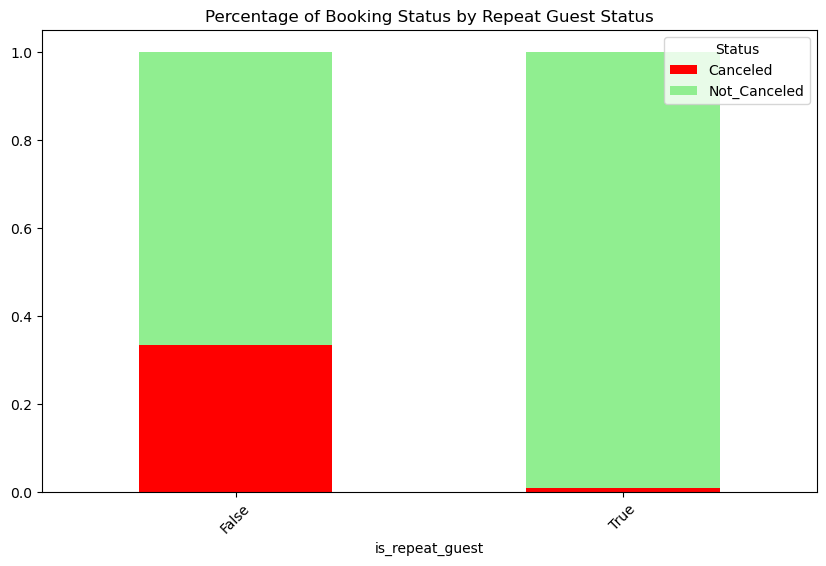

In [ ]:
df['is_repeat_guest'] = df['no_of_previous_bookings_not_canceled'] > 0

loyalty_analysis = pd.crosstab(df['is_repeat_guest'], df['booking_status'], normalize='index')
loyalty_analysis.plot(kind='bar', stacked=True, figsize=(10, 6), color=['red', 'lightgreen'])
plt.title('Percentage of Booking Status by Repeat Guest Status')
plt.legend(title='Status', loc='upper right')
plt.xticks(rotation=45)
plt.show()

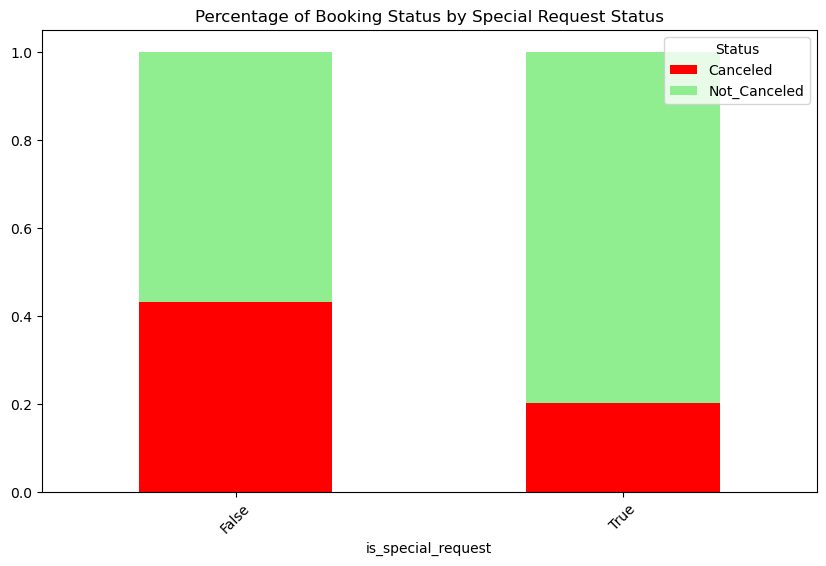

In [ ]:
df['is_special_request'] = df['no_of_special_requests'] > 0
special_request_analysis = pd.crosstab(df['is_special_request'], df['booking_status'], normalize='index')
special_request_analysis.plot(kind='bar', stacked=True, figsize=(10, 6), color=['red', 'lightgreen'])
plt.title('Percentage of Booking Status by Special Request Status')
plt.legend(title='Status', loc='upper right')
plt.xticks(rotation=45)
plt.show()

In [ ]:
print(f"Maximum price: {df['avg_price_per_room'].max()}")
print(f"Minimum price: {df['avg_price_per_room'].min()}")
df.loc[df['avg_price_per_room'] == 0, 'avg_price_per_room'].shape

Maximum price: 540.0
Minimum price: 0.0


(545,)

<Figure size 1000x600 with 0 Axes>

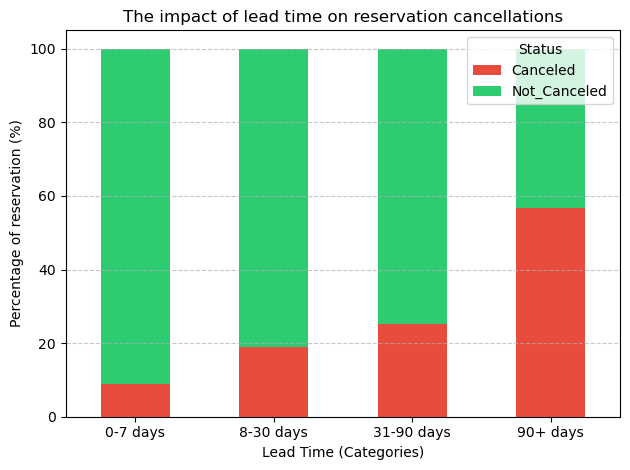

In [ ]:
bins = [0, 7, 30, 90, float('inf')]
labels = ['0-7 days', '8-30 days', '31-90 days', '90+ days']
df['lead_time_category'] = pd.cut(df['lead_time'], bins=bins, labels=labels, include_lowest=True)

lead_time_analysis = pd.crosstab(df['lead_time_category'], df['booking_status'], normalize='index') * 100

plt.figure(figsize=(10, 6))
lead_time_analysis.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'])
plt.title('The impact of lead time on reservation cancellations')
plt.xlabel('Lead Time (Categories)')
plt.ylabel('Percentage of reservation (%)')
plt.xticks(rotation=0)
plt.legend(title='Status', labels=['Canceled', 'Not_Canceled'], loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Conclusion

* Imbalance of target class: ~67% not canceled and ~33% canceled
* Greater the number of special requests higher the chance of booking not being canceled
* No data missing
* Existance of data anomalies, avg_price_per_room equal 0 in 545 reservations
* no_of_special_requests and lead_time are strong class separators and can be good predictors
* Minimal correlation of features
* Repeated booking significantly reduces probability of cancelation

In [ ]:
# df.loc[df['avg_price_per_room'] == 0, 'avg_price_per_room'] = df['avg_price_per_room'].median() # do zastanowienia